In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import scipy.optimize as scippy
import scipy.stats as scist
from numpy.fft import fft, ifft
import os
import shutil
from numba import njit, prange
from scipy.integrate import quad

from matplotlib import animation
plt.rc('animation', html='jshtml')

plt.rc("xtick", labelsize=20, top=True, direction="in")
plt.rc("ytick", labelsize=20, right=True, direction="in")
plt.rc("axes", titlesize=26)
plt.rc("axes", labelsize=26)
plt.rc("legend", fontsize=26)

In [3]:
# Simulation parameters
N = 200

sigma = 1.0
rho = 1.0 / (sigma**2)
L = np.sqrt(N / rho)

kappa = 4.0 # kappa*sigma=4
r_cut = 6.0 / kappa

gamma = 1.0 # gamma=xi from previously

kBT = 1.0
D = kBT / gamma # Diffusion constant via. Einstein-Smoluchowski

U_0 = 2.5
V_0 = U_0 * kBT

tau = 1.0 * gamma * sigma**2 / V_0 # Time unit for everything
dt = 1e-4 * tau
t_equil = 10.0 * tau
t_prod = 10.0 * tau
# t_sim = t_equil + t_prod

n_steps_equil = int(t_equil / dt)
n_steps_prod = int(t_prod / dt)

N_save = 10

print("Velocity associated with Brownian motion (see note): ", np.sqrt(2*D/dt))

Velocity associated with Brownian motion (see note):  223.60679774997897


In [4]:
# Minimum image convention
@njit(fastmath=True)
def min_image(dx, L):
    return dx - L * np.round(dx / L)

# Might want to smoothe the cutoff later
@njit(fastmath=True)
def V_Yuk(r):
    if 0 < r < r_cut:
        return V_0*sigma/r * np.exp( -kappa*(r-sigma) )
    elif r >= r_cut:
        return 0.0
    else:
        raise ValueError

# Quotient rule derivative; think it's correct like this
@njit(fastmath=True)
def F_Yuk(r):
    if 0 < r < r_cut:
        return V_0*sigma * np.exp( -kappa*(r-sigma) ) * (kappa*r + 1) / r**2
    elif r >= r_cut:
        return 0.0
    else:
        raise ValueError

# Intialize particles on a 2D grid, deleting some randomly if N isn't a square number
def init_grid(L, N):
    # Find smallest integer grid size n such that n^2 >= N
    n = int(np.ceil(np.sqrt(N)))

    # Build n×n grid
    coords = np.linspace(0.5*sigma, L - 0.5*sigma, n)
    X, Y= np.meshgrid(coords, coords, indexing='ij')
    pts = np.column_stack([X.ravel(), Y.ravel()])

    # Randomly choose exactly N points, implicitly deleting the rest by replace=False
    idx = np.random.choice(len(pts), N, replace=False)
    return pts[idx]

# Compute the forces using the Yukawa interaction
@njit(fastmath=True)
def compute_forces(pos):
    forces = np.zeros((N, 2))

    for i in range(N):
        xi, yi = pos[i]

        for j in range(i + 1, N): # <-- Only compute j > i to utilize the symmetry
            dx = min_image(xi - pos[j, 0], L)
            dy = min_image(yi - pos[j, 1], L)
            r = np.sqrt(dx*dx + dy*dy)

            F_mag = F_Yuk(r) # Magnitude of the force

            fx = F_mag * dx / r
            fy = F_mag * dy / r

            # Apply Newton's third law / symmetry of the force matrix:
            forces[i, 0] += fx
            forces[i, 1] += fy

            forces[j, 0] -= fx
            forces[j, 1] -= fy
            
    return forces

# Brownian Dynamics integration step with only the Yukawa force
@njit(fastmath=True)
def bd_step_equil(pos):
    F_matrix = compute_forces(pos)
    noise = np.sqrt(2 * kBT * dt / gamma) * np.random.normal(0.0, 1.0, (N, 2)) # Add thermal noise
    pos = pos + dt * F_matrix / gamma + noise # Update positions with forces and noise

    return pos

# Brownian Dynamics integration step with species-based external driving
@njit(fastmath=True)
def bd_step_drive(pos, species):
    F_matrix = compute_forces(pos)
    F_matrix[:,0] += species * F_D # # external driving force

    noise = np.sqrt(2 * kBT * dt / gamma) * np.random.normal(0.0, 1.0, (N, 2)) # Add thermal noise
    pos = pos + dt * F_matrix / gamma + noise # Update positions with forces and noise

    return pos

# g(r) computation
@njit
def compute_gr(pos, r_max, dr):
    n_bins = int(r_max / dr)
    hist = np.zeros(n_bins)

    for i in range(N):
        xi, yi = pos[i]
        for j in range(i+1, N):
            dx = min_image(xi - pos[j,0], L)
            dy = min_image(yi - pos[j,1], L)
            r = np.sqrt(dx*dx + dy*dy)

            if r < r_max:
                bin_idx = int(r / dr)
                hist[bin_idx] += 2.0

    return hist

#MSD computation
@njit(fastmath=True)
def compute_msd(pos, pos0):
    msd = 0.0

    for i in range(N):
        dx = pos[i, 0] - pos0[i, 0]
        dy = pos[i, 1] - pos0[i, 1]

        # minimum image convention
        # dx -= L * np.round(dx / L)
        # dy -= L * np.round(dy / L)

        msd += dx*dx + dy*dy

    return msd / N

r_l = 1/(2*np.sqrt(rho))
# Order parameter computation for SEPERATED left-right flag lists
def compute_Phi(list_L, list_R):
    Phi = 0.0

    # Essentially just checks for each 'left' particle whether there exists a 'right' particle s.t. the criteria 'fails',
    # and phi=0 for the left particle
    for part in list_L:
        phi = 1.0 # Candidate for ordered particle
        for test in list_R:
            sep_vec = part - test
            sep_vec_image = sep_vec - L * np.round(sep_vec / L) # minimum image
            sep = np.linalg.norm(sep_vec_image)
            if sep <= r_l:
                phi = 0.0
        Phi += phi
    
    # Same deal for the right particles being tested
    for part in list_R:
        phi = 1.0 # Candidate for ordered particle
        for test in list_L:
            sep_vec = part - test
            sep_vec_image = sep_vec - L * np.round(sep_vec / L) # minimum image
            sep = np.linalg.norm(sep_vec_image)
            if sep <= r_l:
                phi = 0.0
        Phi += phi
    
    Phi = Phi / N
    return Phi

# Simply take a step to do velocities as finite-difference, the 1dt timestep isn't saved
def compute_velocities(pos, species):
    pos_t = pos.copy()
    pos = bd_step_drive(pos, species)
    velocities = (pos - pos_t) / dt
    return np.abs(velocities)

def compute_velocities_x(pos, species):
    pos_t = pos.copy()
    pos_t = np.array([pos_t[i, 0] for i in range(len(pos_t))])
    pos = bd_step_drive(pos, species)
    pos = np.array([pos[i, 0] for i in range(len(pos_t))])
    velocities = (pos - pos_t) / dt
    return np.abs(velocities)

In [5]:
F_Ds = np.linspace(0, 1500, 4) * kBT / sigma
for F_D in F_Ds:
    pos = init_grid(L, N)

    # Species labels f_i = ±1
    species = np.ones(N)
    species[:N // 2] = -1
    np.random.shuffle(species)

    print("Running equilibration period ...")

    # Equilibration
    for step in range(n_steps_equil):
        pos = bd_step_drive(pos, species)

    print("Equilibration done.")

    # Main simulation
    v_R_avs = []
    print("Running measurement period ...")
    for step in range(n_steps_prod):
            pos = bd_step_drive(pos, species)

            if step % (n_steps_prod // N_save) == 0:
                    print(f"Progress: {100 * step / n_steps_prod:.0f}%")

                    v_s = compute_velocities(pos, species)
                    v_Rs = v_s[species==1]
                    v_R_avs.append(np.mean(v_Rs))
                    # print(np.mean(v_Rs))

    print("Measurement run finished.")

    data_row = np.array([[F_D, np.mean(v_R_avs)]])

    with open('task4_ab.txt', 'ab') as f:
        np.savetxt(
            f,
            data_row,
            fmt='%.8e',
            delimiter='\t'
        )


Running equilibration period ...
Equilibration done.
Running measurement period ...
Progress: 0%
Progress: 10%
Progress: 20%
Progress: 30%
Progress: 40%
Progress: 50%
Progress: 60%
Progress: 70%
Progress: 80%
Progress: 90%


KeyboardInterrupt: 

In [6]:
# print(r'$F_D$ [$k_B T / \sigma$]: ', F_D)

# print("Average velocity of particles moving right: ", np.mean(v_R_avs))

# print("Velocity associated with Brownian motion (see note): ", np.sqrt(2*D/dt))

In [ ]:
F_Ds, v_As = np.loadtxt('task4_ab.txt', unpack=True)

dF = F_Ds[1] - F_Ds[0] # Make sure to change if spacing uneven

dv_As = [(v_As[i+1] - v_As[i])/dF for i in range(len(v_As)-1)]
F_mids = [0.5*(F_Ds[i+1] + F_Ds[i]) for i in range(len(F_Ds)-1)]

Text(0, 0.5, '$\\langle v_R \\rangle$ [$\\sigma/\\tau_{BD}$]')

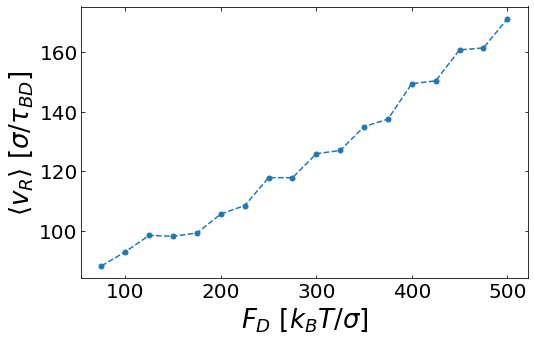

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(F_Ds, v_As, ls='--', marker='.', ms=10)
ax.set_xlabel(r'$F_D$ [$k_B T / \sigma$]')
ax.set_ylabel(r'$\langle v_R \rangle$ [$\sigma/\tau_{BD}$]') # Unsure about the unit

Text(0, 0.5, '$\\frac{d}{dF_D}\\langle v_R \\rangle$ [$\\sigma^2/\\tau_{BD} k_B T$]')

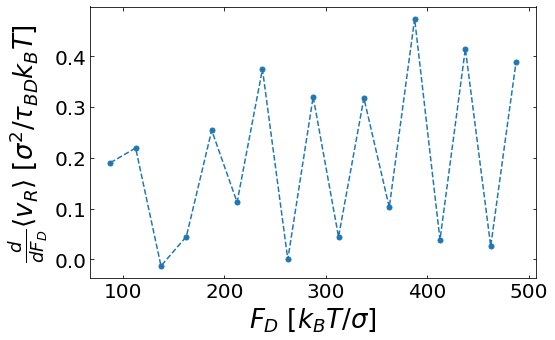

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(F_mids, dv_As, ls='--', marker='.', ms=10)
ax.set_xlabel(r'$F_D$ [$k_B T / \sigma$]')
ax.set_ylabel(r'$\frac{d}{dF_D}\langle v_R \rangle$ [$\sigma^2/\tau_{BD} k_B T$]') # Unsure about the unit